# Modularity Maximization vs. Stochastic Block Model on the Left oviIN Inputs (V3)

### Dataset: FAFB FlyWire v783

This notebook asks: **does the community structure in the oviIN input subconnectome depend on the method used to detect it?** Two independent methods — one based on modularity optimization (RenEEL) and one based on statistical inference (degree-corrected SBM) — are applied to the same network. If they find the same communities, the structure is robust and likely reflects real biology.

**Section 0** — Environment setup (run once, restart, then skip).

**Section 1** — Data loading: identify the left oviIN in FlyWire, extract its input subconnectome (all presynaptic neurons and the connections among them), and fetch per-synapse xyz coordinates.

**Section 2** — Modularity maximization using RenEEL at chi=0. This is the lab's established method, used in the published analysis of oviIN_R in the Hemibrain.

**Section 3** — Degree-corrected SBM via graspologic. A fundamentally different approach — statistical inference rather than score optimization.

**Section 4** — Comparison using pairwise Jaccard similarity and containment scores. Containment reveals whether the two methods agree at different scales (hierarchical nesting).

**Section 5** — Chi-sweep: RenEEL at multiple resolutions to test whether the methods converge at some scale.

**Section 6** — Merge-based coarsening: an alternative to negative chi (which times out) — merge RenEEL modules to match the SBM's scale and compare directly.

**Section 7** — Biological characterization: do the two methods partition by different biological features (neurotransmitter type, neuropil, cell class)?

**Section 8** — SBM variability: run the SBM 10 times to assess partition stability.

**Section 9** — Skeleton overlay: neuron morphology with synapses colored by community for visual comparison with Hemibrain results.

*Source: Gutierrez Lab, Barnard College. Data from FlyWire (Dorkenwald et al., 2024).*

---
# Section 0: Environment Setup

Graspologic requires `numpy < 2.0`, and the skeleton overlay uses `navis` and `fafbseg` for fetching neuron morphology from FlyWire. Installing all dependencies upfront prevents conflicts.

**Run this cell once, restart the runtime (Runtime → Restart runtime), then skip directly to Section 1.**

In [1]:
# ──────────────────────────────────────────────────────────
# CELL 0.1 — Install pinned dependencies
# ──────────────────────────────────────────────────────────
!pip install "numpy<2.0,>=1.24" "pandas>=1.5,<3.0" graspologic caveclient -q
!pip install navis fafbseg cloud-volume -q
print("Dependencies installed. Restart runtime, then skip to Section 1.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 112.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.4/93.4 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 917.8/917.8 kB 64.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 100.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.6/364.6 kB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.3/192.3 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 140.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

---
# Section 1: Data Loading

This section loads the FAFB FlyWire v783 dataset, identifies the left oviposition inhibitory neuron (oviIN), and extracts the **input subconnectome** — all neurons that provide synaptic input to the oviIN and all the directed connections among those neurons. This subconnectome is the network whose community structure we analyze throughout the notebook.

We also fetch per-synapse xyz coordinates from the FlyWire `synapses_nt_v1` table via `caveclient`. These coordinates record *where* on the oviIN dendrite each synapse lands (in nanometers), allowing us to visualize whether neurons in the same community target the same region of the dendrite — the spatial localization question central to the lab's oviIN research.

## 1.1 Imports

In [1]:
# ──────────────────────────────────────────────────────────
# CELL 1.1 — Imports
# ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from collections import Counter
import subprocess, sys, os, re
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')
print("Imports complete.")

Mounted at /content/drive
Imports complete.


## 1.2 Load FAFB tables

Three CSV files are needed: the connections edge list (`connections_princeton.csv` — who connects to whom and with how many synapses), cell type annotations (`consolidated_cell_types.csv` — to find "oviIN"), and classification (`classification.csv` — to determine left vs. right side).

In [2]:
# ──────────────────────────────────────────────────────────
# CELL 1.2 — Load FAFB tables
# ──────────────────────────────────────────────────────────
DATA_DIR = '/content/drive/MyDrive/Barnard Drosophila/FAFB/Data_Files/'

connections = pd.read_csv(DATA_DIR + 'connections_princeton.csv')
cell_types = pd.read_csv(DATA_DIR + 'consolidated_cell_types.csv')
classification = pd.read_csv(DATA_DIR + 'classification.csv')

print(f"connections: {len(connections):,}, cell_types: {len(cell_types):,}, classification: {len(classification):,}")

# ── Sanity check ──
assert list(connections.columns) == ['pre_root_id','post_root_id','neuropil','syn_count','nt_type']
assert 'primary_type' in cell_types.columns
assert 'side' in classification.columns
print("✓ Column schema checks passed.")

connections: 5,342,446, cell_types: 138,327, classification: 139,255
✓ Column schema checks passed.


## 1.3 Identify the left oviIN

In [3]:
# ──────────────────────────────────────────────────────────
# CELL 1.3 — Find the left oviIN root_id
# ──────────────────────────────────────────────────────────
ovi = cell_types[cell_types['primary_type'] == 'oviIN']
ovi_full = ovi.merge(classification[['root_id', 'side']], on='root_id', how='left')
print("oviIN neurons in FAFB:")
print(ovi_full[['root_id', 'primary_type', 'side']].to_string(index=False))

oviIN_left_id = ovi_full.loc[ovi_full['side'] == 'left', 'root_id'].iloc[0]
print(f"\nLeft oviIN root_id: {oviIN_left_id}")

# ── Sanity check ──
assert (ovi_full['side'] == 'left').sum() == 1
print("✓ Exactly 1 left oviIN found.")

oviIN neurons in FAFB:
           root_id primary_type  side
720575940628360506        oviIN  left
720575940625741287        oviIN right

Left oviIN root_id: 720575940628360506
✓ Exactly 1 left oviIN found.


## 1.4 Extract the input subconnectome

The input subconnectome consists of all neurons presynaptic to the left oviIN (its "inputs") plus all directed connections among those input neurons. This is the network whose community structure we analyze — not just the direct connections to the oviIN, but the full pattern of connectivity within its input population.

In [4]:
# ──────────────────────────────────────────────────────────
# CELL 1.4 — Extract input subconnectome
# ──────────────────────────────────────────────────────────
inputs_to_ovi = connections[connections['post_root_id'] == oviIN_left_id]
input_ids = set(inputs_to_ovi['pre_root_id'].unique())
print(f"Presynaptic partners: {len(input_ids):,}")
print(f"Synapses onto left oviIN: {inputs_to_ovi['syn_count'].sum():,}")

subconn = connections[
    connections['pre_root_id'].isin(input_ids) &
    connections['post_root_id'].isin(input_ids)
].copy()
print(f"\nSubconnectome: {len(subconn):,} edges, weight {subconn['syn_count'].sum():,}")

# ── Sanity checks ──
assert len(input_ids) > 0 and len(subconn) > 0
assert subconn['syn_count'].min() > 0
print("✓ Subconnectome integrity checks passed.")

Presynaptic partners: 243
Synapses onto left oviIN: 2,913

Subconnectome: 2,542 edges, weight 23,658
✓ Subconnectome integrity checks passed.


## 1.5 Build integer-indexed edge list

Both community detection methods need integer node IDs (0 to N-1). We create a bidirectional mapping between FlyWire root_ids and integers. This also prevents 18-digit root_ids from overflowing buffers in the C-based RenEEL binary.

In [5]:
# ──────────────────────────────────────────────────────────
# CELL 1.5 — Integer node mapping
# ──────────────────────────────────────────────────────────
all_nodes = sorted(input_ids)
node_to_idx = {nid: i for i, nid in enumerate(all_nodes)}
idx_to_node = {i: nid for nid, i in node_to_idx.items()}
n_nodes = len(all_nodes)

edges_df = subconn[['pre_root_id', 'post_root_id', 'syn_count']].copy()
edges_df['src'] = edges_df['pre_root_id'].map(node_to_idx).astype(int)
edges_df['tgt'] = edges_df['post_root_id'].map(node_to_idx).astype(int)

print(f"Subconnectome: {n_nodes} nodes, {len(edges_df):,} directed edges")

# ── Sanity check ──
assert edges_df['src'].between(0, n_nodes-1).all()
assert edges_df['tgt'].between(0, n_nodes-1).all()
print("✓ Edge list checks passed.")

Subconnectome: 243 nodes, 2,542 directed edges
✓ Edge list checks passed.


## 1.6 Fetch synapse coordinates

Per-synapse xyz positions are not in the Drive CSVs. We use `caveclient` to query the `synapses_nt_v1` table for all synapses where the postsynaptic partner is the left oviIN. Each synapse has a `post_pt_position` — the [x, y, z] coordinates (in nanometers) of where the synapse lands on the oviIN dendrite.

The synapse table is unthresholded and includes many more presynaptic partners than the connections table. All partners from the connections table should appear in the synapse table.

In [6]:
# ──────────────────────────────────────────────────────────
# CELL 1.6a — Connect to caveclient
# ──────────────────────────────────────────────────────────
from caveclient import CAVEclient
from google.colab import userdata

client = CAVEclient('flywire_fafb_public', auth_token=userdata.get('CAVE_TOKEN'),
                     server_address='https://global.daf-apis.com')
client.materialize.version = 783
print(f"Connected to CAVE v{client.materialize.version}")

Connected to CAVE v783


In [7]:
# ──────────────────────────────────────────────────────────
# CELL 1.6b — Fetch all synapses onto left oviIN (1-2 min)
# ──────────────────────────────────────────────────────────
print("Fetching synapses...")
ovi_syns = client.materialize.query_table(
    'synapses_nt_v1', filter_equal_dict={'post_pt_root_id': oviIN_left_id}
)
ovi_syns['post_x'] = ovi_syns['post_pt_position'].apply(lambda p: p[0])
ovi_syns['post_y'] = ovi_syns['post_pt_position'].apply(lambda p: p[1])
ovi_syns['post_z'] = ovi_syns['post_pt_position'].apply(lambda p: p[2])

print(f"Synapses: {len(ovi_syns):,}")
print(f"X: [{ovi_syns['post_x'].min():,}, {ovi_syns['post_x'].max():,}]")
print(f"Y: [{ovi_syns['post_y'].min():,}, {ovi_syns['post_y'].max():,}]")
print(f"Z: [{ovi_syns['post_z'].min():,}, {ovi_syns['post_z'].max():,}]")

# ── Sanity checks ──
assert len(ovi_syns) > 0
assert ovi_syns[['post_x','post_y','post_z']].notna().all().all()
print("✓ Synapse data checks passed.")

Fetching synapses...
Synapses: 9,700
X: [421,020, 589,280]
Y: [94,904, 306,896]
Z: [27,600, 177,760]
✓ Synapse data checks passed.


In [8]:
# ──────────────────────────────────────────────────────────
# CELL 1.6c — Cross-check synapse vs connections tables
# ──────────────────────────────────────────────────────────
syn_pre = set(ovi_syns['pre_pt_root_id'].unique())
print(f"Synapse table partners: {len(syn_pre):,}")
print(f"Connections table partners: {len(input_ids):,}")
print(f"Overlap: {len(syn_pre & input_ids):,}")
print(f"Only in connections: {len(input_ids - syn_pre):,}")

# ── Sanity check ──
assert input_ids - syn_pre == set()
print("✓ All connection partners found in synapse table.")

Synapse table partners: 2,007
Connections table partners: 243
Overlap: 243
Only in connections: 0
✓ All connection partners found in synapse table.


---
# Section 2: Modularity Maximization (RenEEL)

Modularity maximization partitions a network to maximize Q — the fraction of within-community edges minus what would be expected under a degree-preserving null model. Q ranges from -0.5 to 1; values above ~0.3 indicate meaningful community structure.

RenEEL is a spectral method that maintains an ensemble of candidate partitions and iteratively refines them. At chi=0 this is standard modularity. Negative chi produces coarser partitions (fewer, larger modules); positive chi produces finer ones (more, smaller modules). We start with chi=0 — the same setting used in the lab's published analysis of oviIN_R inputs in the Hemibrain (Weber Langstaff et al., 2025).

The pipeline has three stages:
1. `format_edgelist.py` — renumbers nodes consecutively, creates a key file.
2. `work.sh` — preprocesses the edge list (sorting, cleaning, degree computation).
3. `a.out` — runs RenEEL. Requires 6 arguments: `krg copy1 copy2 seed chi filename`.

## 2.1 Set up GCM pipeline

In [9]:
# ──────────────────────────────────────────────────────────
# CELL 2.1 — Download pipeline and compile a.out
# ──────────────────────────────────────────────────────────
os.chdir('/content')
pipeline_files = {
    'gcm_script.py':      'https://raw.githubusercontent.com/Gutierrez-lab/oviIN-inputs/main/gcm_pipeline/gcm_script.py',
    'format_edgelist.py': 'https://raw.githubusercontent.com/Gutierrez-lab/oviIN-inputs/main/gcm_pipeline/format_edgelist.py',
    'work.sh':            'https://raw.githubusercontent.com/Gutierrez-lab/oviIN-inputs/main/gcm_pipeline/work.sh',
}
for fname, url in pipeline_files.items():
    if not os.path.exists(fname):
        subprocess.run(["wget", "-q", url, "-O", fname], check=True)
        print(f"Downloaded {fname}")
    else:
        print(f"  {fname} exists")

subprocess.run(["chmod", "+x", "work.sh"], check=True)

if not os.path.exists("generalized-modularity-density"):
    subprocess.run(["git", "clone", "https://github.com/prameshsingh/generalized-modularity-density.git"],
                   check=True, capture_output=True)

# Compiled with FORTIFY_SOURCE disabled — Colab's newer glibc triggers buffer
# overflow protections on the fixed-size char arrays in main.c.
subprocess.run(["gcc", "-O3", "-U_FORTIFY_SOURCE", "-D_FORTIFY_SOURCE=0", "-fno-stack-protector",
    "generalized-modularity-density/main.c", "generalized-modularity-density/help.c",
    "generalized-modularity-density/rg.c", "-lm", "-fopenmp", "-o", "a.out"], check=True)
subprocess.run(["chmod", "+x", "a.out"], check=True)

sys.path.insert(0, os.getcwd())
from gcm_script import run_format_script

# ── Sanity check ──
assert os.path.exists('a.out')
print("\n✓ GCM pipeline ready.")

Downloaded gcm_script.py
Downloaded format_edgelist.py
Downloaded work.sh

✓ GCM pipeline ready.


## 2.2 RenEEL helper function

We wrap the three-stage pipeline into a reusable function so it can be called at different chi values in the sweep (Section 5). The function handles timeouts gracefully — extreme chi values can cause RenEEL to converge very slowly.

In [10]:
# ──────────────────────────────────────────────────────────
# CELL 2.2 — run_reneel_at_chi()
# ──────────────────────────────────────────────────────────
import string, random

def run_reneel_at_chi(edges_df, idx_to_node, chi=0.0, seed=12345, label=''):
    """Run RenEEL at a given chi. Returns (partition_df, q_value) or (None, None)."""
    # Symmetrize (RenEEL needs undirected edges)
    el = edges_df[['src', 'tgt', 'syn_count']].copy()
    el_rev = el.rename(columns={'src': 'tgt', 'tgt': 'src'})
    el_both = pd.concat([el, el_rev], ignore_index=True)
    el_und = el_both.groupby(['src', 'tgt'], as_index=False)['syn_count'].sum()
    el_und = el_und[el_und['src'] != el_und['tgt']]

    tag = label or ''.join(random.choices(string.ascii_lowercase, k=6))
    fname = f'ovi_{tag}'
    el_und.to_csv(f'/content/{fname}', sep=' ', header=False, index=False)

    run_format_script(f'/content/{fname}')
    fmt_name = f'{fname}_formatted'

    subprocess.run(['bash', 'work.sh', fmt_name],
                   capture_output=True, text=True, timeout=120, cwd='/content')

    try:
        result = subprocess.run(
            ['./a.out', '2', '5', '2', str(seed), str(chi), fmt_name],
            capture_output=True, text=True, timeout=600, cwd='/content')
    except subprocess.TimeoutExpired:
        print(f"  chi={chi:+.2f}: TIMED OUT, skipping")
        return None, None

    if result.returncode != 0:
        print(f"  chi={chi:+.2f}: a.out failed, skipping")
        return None, None

    q_value = None
    for line in result.stdout.split('\n'):
        match = re.search(r'Qfinal=([0-9.]+)', line)
        if match:
            q_value = float(match.group(1))

    part_file = f'/content/partition_{fmt_name}'
    key_file = f'/content/{fname}_key'
    if not os.path.exists(part_file):
        print(f"  chi={chi:+.2f}: no partition file")
        return None, None

    part_raw = pd.read_csv(part_file, sep='\s+', header=None, names=['module'])
    key_df = pd.read_csv(key_file, sep='\s+', header=None, names=['fid', 'oid'])
    partition = pd.DataFrame({
        'formatted_id': range(len(part_raw)),
        'module': part_raw['module'].values,
        'node_id': key_df['oid'].values
    })
    partition['root_id'] = partition['node_id'].map(idx_to_node)
    n_mod = partition['module'].nunique()
    print(f"  chi={chi:+.2f}: {n_mod} modules, Q={q_value}")
    return partition, q_value

print("run_reneel_at_chi() defined.")

run_reneel_at_chi() defined.


## 2.3 Run RenEEL at chi=0

In [11]:
# ──────────────────────────────────────────────────────────
# CELL 2.3 — RenEEL baseline (chi=0)
# ──────────────────────────────────────────────────────────
reneel_partition, reneel_q = run_reneel_at_chi(edges_df, idx_to_node, chi=0.0, label='chi0')
n_modules = reneel_partition['module'].nunique()
print(f"\nModule sizes:")
print(reneel_partition['module'].value_counts().sort_index())

# ── Sanity checks ──
assert reneel_partition is not None and n_modules >= 2
assert reneel_q is not None and 0 < reneel_q < 1
print(f"\n✓ RenEEL: {n_modules} modules, Q={reneel_q:.4f}")

  chi=+0.00: 8 modules, Q=0.472201

Module sizes:
module
1    16
2    57
3    34
4    35
5    32
6    49
7     2
8     7
Name: count, dtype: int64

✓ RenEEL: 8 modules, Q=0.4722


## 2.4 Plotting function

This function plots all synapses landing on the oviIN in 3D, colored by the community assignment of the presynaptic neuron. If a community corresponds to a spatially localized territory on the dendrite, synapses of the same color will cluster together.

The function optionally renders the neuron skeleton as a gray wireframe underneath the synapses (used in Section 9).

In [12]:
# ──────────────────────────────────────────────────────────
# CELL 2.4 — plot_synapses_by_group (shared across sections)
# ──────────────────────────────────────────────────────────
def plot_synapses_by_group(syn_df, partition_df, group_col,
                            x_col='post_x', y_col='post_y', z_col='post_z',
                            pre_col='pre_pt_root_id', title='', figsize=(14, 10),
                            elev=20, azim=45, save_path=None, skeleton_lines=None):
    merged = syn_df.merge(partition_df[['root_id', group_col]],
                          left_on=pre_col, right_on='root_id', how='left')
    labeled = merged.dropna(subset=[group_col])
    unlabeled_count = merged[group_col].isna().sum()

    n_groups = int(labeled[group_col].nunique())
    cmap = plt.cm.get_cmap('tab20', max(n_groups, 1))
    group_vals = sorted(labeled[group_col].unique())
    color_map = {g: cmap(i) for i, g in enumerate(group_vals)}

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')

    if skeleton_lines is not None and len(skeleton_lines) > 0:
        lc = Line3DCollection(skeleton_lines, colors='lightgray', alpha=0.2, linewidths=0.3)
        ax.add_collection3d(lc)

    for g in group_vals:
        mask = labeled[group_col] == g
        ax.scatter(labeled.loc[mask, x_col], labeled.loc[mask, y_col],
                   labeled.loc[mask, z_col], c=[color_map[g]], s=3, alpha=0.5,
                   label=f'{group_col.title()} {int(g)} ({mask.sum():,})')

    ax.set_xlabel('X (nm)'); ax.set_ylabel('Y (nm)'); ax.set_zlabel('Z (nm)')
    ax.set_title(title, fontsize=13)
    ax.view_init(elev=elev, azim=azim)
    ax.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), fontsize=7, markerscale=4, frameon=False)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()
    print(f"Labeled: {len(labeled):,}, unlabeled: {unlabeled_count:,}")
    return fig

print("plot_synapses_by_group defined.")

plot_synapses_by_group defined.


## 2.5 Plot RenEEL modules on skeleton

Saved: reneel_synapses.png


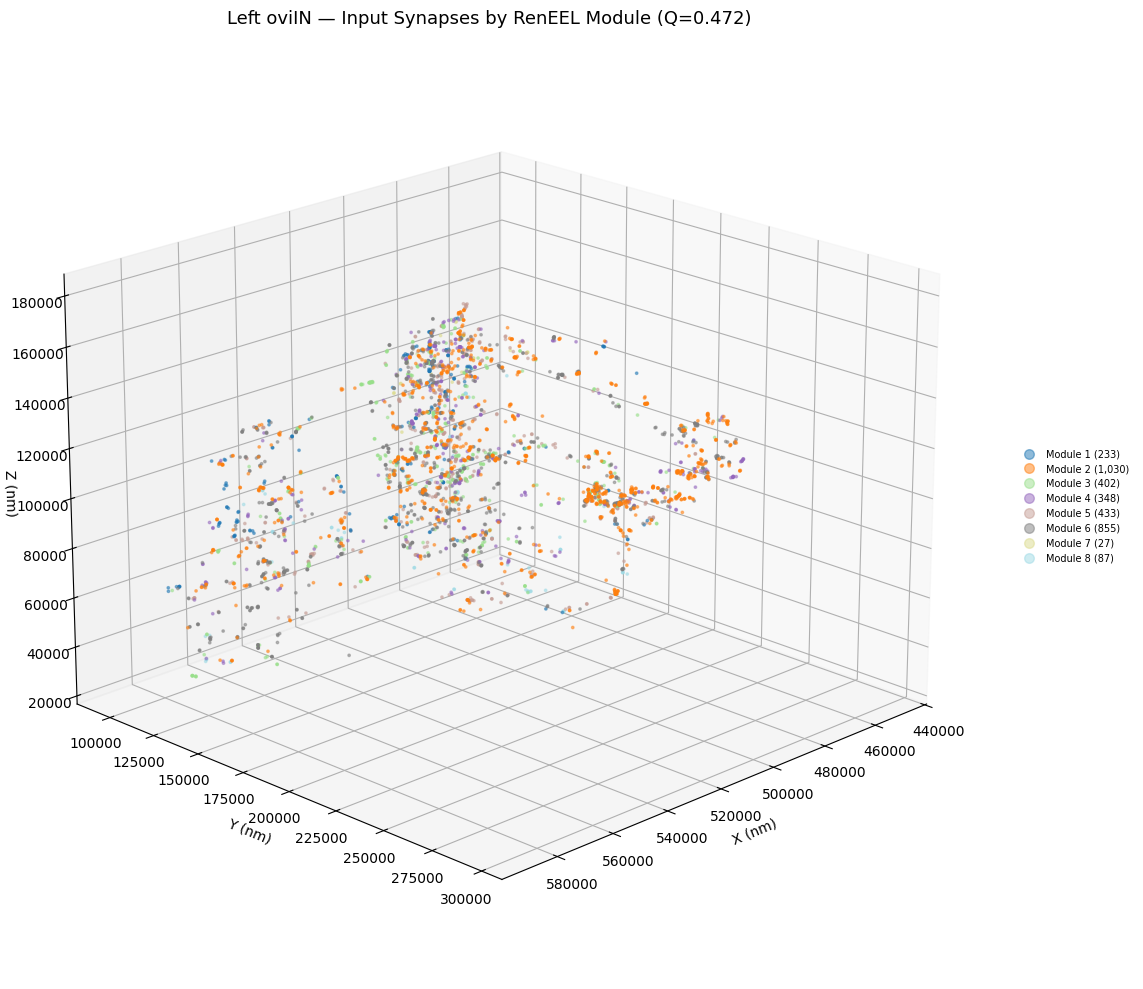

Labeled: 3,415, unlabeled: 6,285


In [13]:
# ──────────────────────────────────────────────────────────
# CELL 2.5 — Skeleton plot colored by RenEEL module
# ──────────────────────────────────────────────────────────
fig_reneel = plot_synapses_by_group(
    ovi_syns, reneel_partition, group_col='module',
    title=f'Left oviIN — Input Synapses by RenEEL Module (Q={reneel_q:.3f})',
    save_path='reneel_synapses.png')

---
# Section 3: Degree-Corrected Stochastic Block Model

## Why Degree-Corrected SBM?

The SBM takes a fundamentally different approach: instead of optimizing a score, it asks "what generative model best explains how this network was produced?" Each node belongs to a block, and edge probabilities depend on block memberships.

The **degree-corrected** variant adds per-node degree parameters — essential for connectome data where neurons range from sparsely to densely connected. This matches RenEEL's degree-preserving null model.

| | **RenEEL** | **DC-SBM (our approach)** |
|---|---|---|
| **Objective** | Maximize modularity Q | Maximize likelihood (via BIC) |
| **Algorithm** | Spectral ensemble refinement | Spectral embedding + GMM |
| **# communities** | Determined by optimization | Selected by BIC |
| **Null model** | Degree-preserving | Degree-corrected |

We use Adjacency Spectral Embedding (ASE) to represent each node as a point in a low-dimensional space where nearby points have similar connectivity patterns, then cluster with a Gaussian Mixture Model that selects the number of blocks via BIC. We try all 4 covariance types (full, tied, diagonal, spherical) to avoid underfitting.

## 3.1 Build adjacency matrix

In [14]:
# ──────────────────────────────────────────────────────────
# CELL 3.1 — Build adjacency matrix
# ──────────────────────────────────────────────────────────
from graspologic.embed import AdjacencySpectralEmbed
from graspologic.cluster import AutoGMMCluster
from scipy.sparse import csr_matrix

A = csr_matrix((edges_df['syn_count'].values, (edges_df['src'].values, edges_df['tgt'].values)),
               shape=(n_nodes, n_nodes))
A_dense = A.toarray().astype(float)

print(f"Adjacency: {A.shape}, nnz: {A.nnz:,}, density: {A.nnz/(n_nodes**2):.4f}")

# ── Sanity check ──
n_unique = edges_df.groupby(['src','tgt']).ngroups
assert A.nnz == n_unique, f"FAIL: nnz {A.nnz} != unique edges {n_unique}"
print("✓ Adjacency matrix checks passed.")

Adjacency: (243, 243), nnz: 1,299, density: 0.0220
✓ Adjacency matrix checks passed.


## 3.2 Spectral embedding

ASE maps each node to a point in low-dimensional space. For directed graphs, it produces separate left (outgoing) and right (incoming) embeddings, which we concatenate to capture both connectivity directions.

In [15]:
# ──────────────────────────────────────────────────────────
# CELL 3.2 — Spectral embedding
# ──────────────────────────────────────────────────────────
ase = AdjacencySpectralEmbed(n_components=None, algorithm='randomized')
X_hat = ase.fit_transform(A_dense)
X_embed = np.concatenate(X_hat, axis=1) if isinstance(X_hat, tuple) else X_hat
print(f"Embedding: {X_embed.shape}")

# ── Sanity check ──
assert X_embed.shape[0] == n_nodes and np.isfinite(X_embed).all()
print("✓ Embedding checks passed.")

Embedding: (243, 12)
✓ Embedding checks passed.


## 3.3 Cluster the embedding

In [16]:
# ──────────────────────────────────────────────────────────
# CELL 3.3 — GMM clustering (auto-selects k via BIC)
# ──────────────────────────────────────────────────────────
max_k = min(20, n_nodes // 5)
gm = AutoGMMCluster(min_components=2, max_components=max(2, max_k),
                     covariance_type=['full', 'tied', 'diag', 'spherical'])
gm.fit(X_embed)
sbm_labels = gm.predict(X_embed)
n_blocks = len(set(sbm_labels))

print(f"DC-SBM: {n_blocks} blocks")
for b, cnt in sorted(Counter(sbm_labels).items(), key=lambda x: -x[1]):
    print(f"  Block {b}: {cnt} nodes")

# ── Sanity check ──
assert n_blocks >= 2 and len(sbm_labels) == n_nodes
print("\n✓ Clustering checks passed.")

DC-SBM: 4 blocks
  Block 1: 176 nodes
  Block 0: 63 nodes
  Block 3: 2 nodes
  Block 2: 2 nodes

✓ Clustering checks passed.


## 3.4 Build SBM partition

In [17]:
# ──────────────────────────────────────────────────────────
# CELL 3.4 — Map block labels to root_ids
# ──────────────────────────────────────────────────────────
sbm_partition = pd.DataFrame({'node_id': range(n_nodes), 'block': sbm_labels})
sbm_partition['root_id'] = sbm_partition['node_id'].map(idx_to_node)
print(f"SBM: {n_blocks} blocks, {len(sbm_partition)} nodes")

# ── Sanity check ──
assert sbm_partition['root_id'].notna().all()
print("✓ SBM partition mapping checks passed.")

SBM: 4 blocks, 243 nodes
✓ SBM partition mapping checks passed.


## 3.5 Plot SBM blocks

Saved: sbm_synapses.png


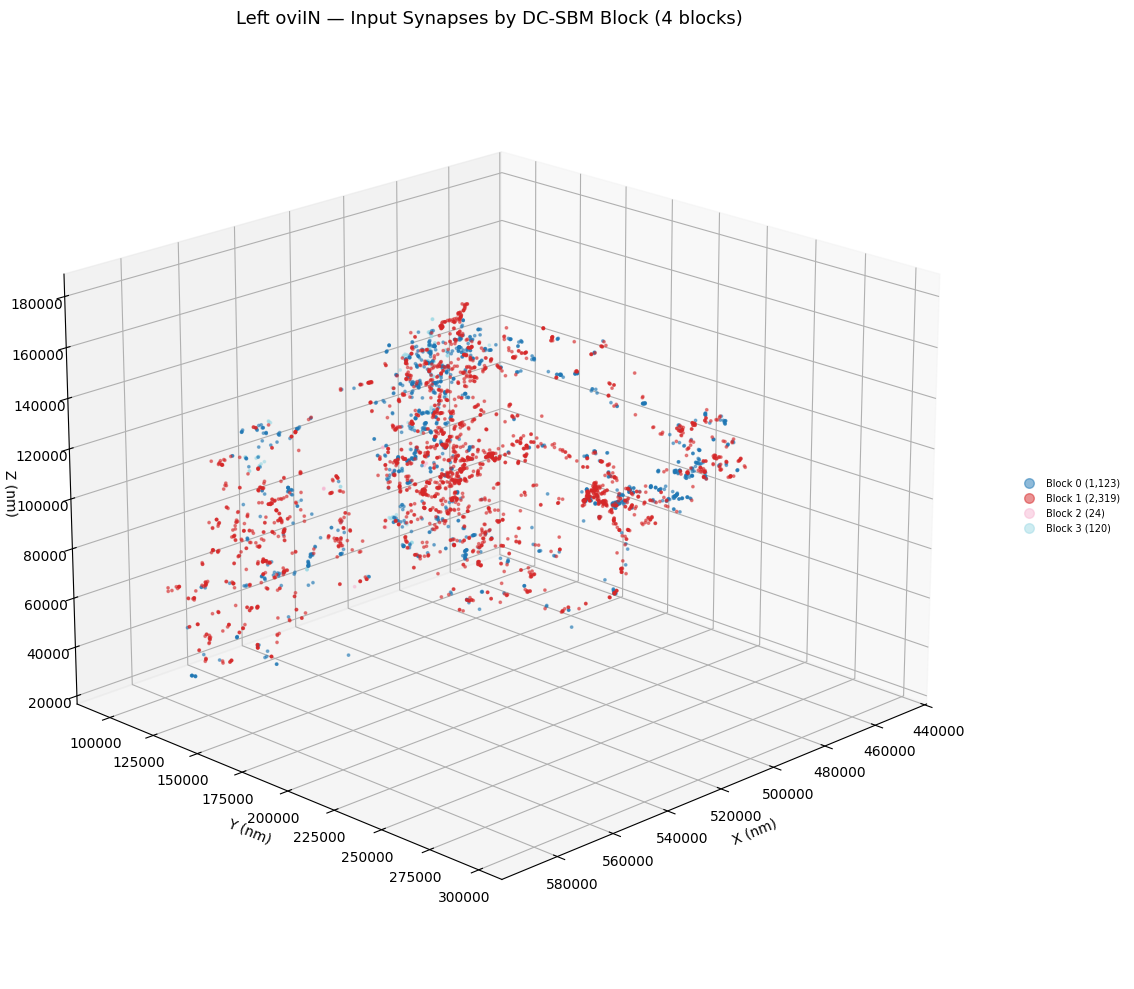

Labeled: 3,586, unlabeled: 6,114


In [18]:
# ──────────────────────────────────────────────────────────
# CELL 3.5 — Skeleton plot colored by SBM block
# ──────────────────────────────────────────────────────────
fig_sbm = plot_synapses_by_group(
    ovi_syns, sbm_partition, group_col='block',
    title=f'Left oviIN — Input Synapses by DC-SBM Block ({n_blocks} blocks)',
    save_path='sbm_synapses.png')

---
# Section 4: Comparison — Jaccard and Containment

We use two complementary metrics:

**Pairwise Jaccard** — J(A,B) = |A∩B| / |A∪B|. Symmetric. A high Jaccard means the two groups contain mostly the same neurons. However, Jaccard penalizes size differences: a module of 35 neurons inside a block of 114 neurons gets J = 35/114 = 0.31 at best, even if the module is entirely contained.

**Containment** — C(A,B) = |A∩B| / |A|. Asymmetric. Asks "what fraction of A's neurons are also in B?" If containment is high but Jaccard is low, A is a subset of B — the methods agree on the grouping but at different scales. This is the hierarchical nesting pattern found by Kunin et al. (2023) when varying chi in RenEEL on the full Hemibrain.

## 4.1 Define comparison functions

In [19]:
# ──────────────────────────────────────────────────────────
# CELL 4.1 — pairwise_jaccard and pairwise_containment
# ──────────────────────────────────────────────────────────
def pairwise_jaccard(pa, pb, la='module', lb='block', nc='root_id'):
    ga = pa.groupby(la)[nc].apply(set).to_dict()
    gb = pb.groupby(lb)[nc].apply(set).to_dict()
    ka, kb = sorted(ga), sorted(gb)
    m = np.zeros((len(ka), len(kb)))
    for i, a in enumerate(ka):
        for j, b in enumerate(kb):
            inter, union = len(ga[a] & gb[b]), len(ga[a] | gb[b])
            m[i,j] = inter/union if union else 0
    return pd.DataFrame(m, index=ka, columns=kb)

def pairwise_containment(pa, pb, la='module', lb='block', nc='root_id'):
    ga = pa.groupby(la)[nc].apply(set).to_dict()
    gb = pb.groupby(lb)[nc].apply(set).to_dict()
    ka, kb = sorted(ga), sorted(gb)
    m = np.zeros((len(ka), len(kb)))
    for i, a in enumerate(ka):
        sa = len(ga[a])
        for j, b in enumerate(kb):
            m[i,j] = len(ga[a] & gb[b]) / sa if sa else 0
    return pd.DataFrame(m, index=ka, columns=kb)

print("Comparison functions defined.")

Comparison functions defined.


## 4.2 Compute Jaccard and Containment

In [20]:
# ──────────────────────────────────────────────────────────
# CELL 4.2 — Compute both metrics
# ──────────────────────────────────────────────────────────
jaccard = pairwise_jaccard(reneel_partition, sbm_partition)
containment = pairwise_containment(reneel_partition, sbm_partition)

print(f"{'Module':>8} {'Size':>5} {'Best Blk':>8} {'Jaccard':>8} {'Contain':>8}")
print("-" * 45)
for mod in jaccard.index:
    size = (reneel_partition['module'] == mod).sum()
    best_c_blk = containment.loc[mod].idxmax()
    best_c = containment.loc[mod].max()
    j_val = jaccard.loc[mod, best_c_blk]
    print(f"{int(mod):>8} {size:>5} {int(best_c_blk):>8} {j_val:>8.3f} {best_c:>8.3f}")

# ── Sanity check ──
assert np.allclose(containment.sum(axis=1), 1.0, atol=0.01)
print(f"\n✓ Containment rows sum to 1.0.")

  Module  Size Best Blk  Jaccard  Contain
---------------------------------------------
       1    16        1    0.079    0.875
       2    57        1    0.183    0.632
       3    34        1    0.129    0.706
       4    35        1    0.141    0.743
       5    32        1    0.130    0.750
       6    49        1    0.197    0.755
       7     2        0    0.016    0.500
       8     7        1    0.022    0.571

✓ Containment rows sum to 1.0.


## 4.3 Heatmaps

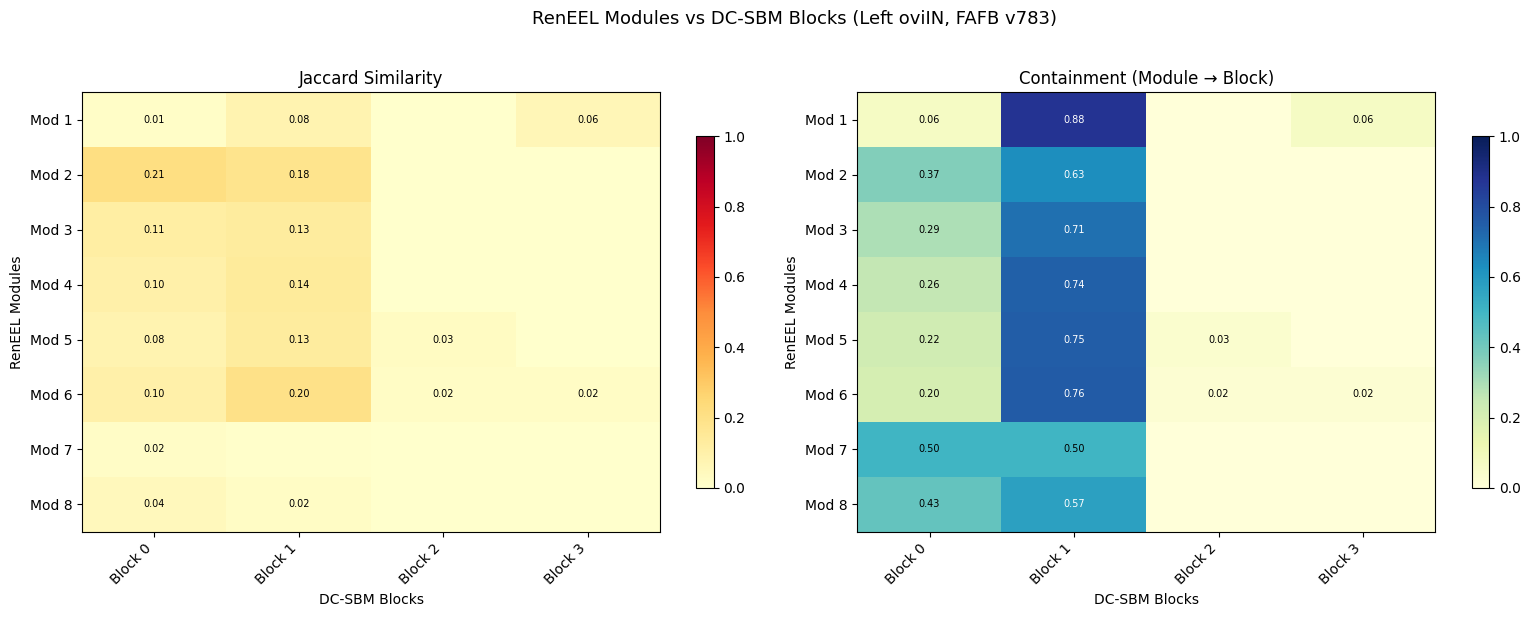

In [21]:
# ──────────────────────────────────────────────────────────
# CELL 4.3 — Side-by-side Jaccard and Containment heatmaps
# ──────────────────────────────────────────────────────────
def plot_comparison_heatmaps(jac_df, con_df, save_path=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    for ax, data, ttl, cm in [(ax1, jac_df, 'Jaccard Similarity', 'YlOrRd'),
                               (ax2, con_df, 'Containment (Module → Block)', 'YlGnBu')]:
        im = ax.imshow(data.values, cmap=cm, aspect='auto', vmin=0, vmax=1)
        ax.set_xticks(range(data.shape[1]))
        ax.set_xticklabels([f'Block {int(c)}' for c in data.columns], rotation=45, ha='right')
        ax.set_yticks(range(data.shape[0]))
        ax.set_yticklabels([f'Mod {int(r)}' for r in data.index])
        ax.set_xlabel('DC-SBM Blocks'); ax.set_ylabel('RenEEL Modules')
        ax.set_title(ttl, fontsize=12)
        for i in range(data.shape[0]):
            for j in range(data.shape[1]):
                v = data.values[i,j]
                if v > 0.01:
                    ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                            fontsize=7, color='white' if v > 0.5 else 'black')
        fig.colorbar(im, ax=ax, shrink=0.8)
    plt.suptitle('RenEEL Modules vs DC-SBM Blocks (Left oviIN, FAFB v783)', fontsize=13, y=1.02)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_comparison_heatmaps(jaccard, containment, save_path='jaccard_containment.png')

## Figure: Side-by-side Jaccard similarity (left) and Containment (right) between RenEEL modules and DC-SBM blocks.

Jaccard (left panel): All values are low — the maximum is 0.21 (Module 2 → Block 0) and no pair exceeds 0.5. This confirms the two methods do not find overlapping communities at a one-to-one level.

Containment (right panel): This tells a richer story. Six of eight modules (Modules 1, 3, 4, 5, 6, and to a lesser extent 2) have their majority contained in Block 1 (63–88%). But none are perfectly contained — every module has 20–37% of its neurons in Block 0. The SBM's boundary cuts through every RenEEL module rather than between them.

Module 7 is the most striking case: split exactly 50/50 between Block 0 and Block 1. The SBM literally bisects this module. Module 1 has the highest containment (88% in Block 1), suggesting it is the most "pure" module from the SBM's perspective.

Blocks 2 and 3 are barely used — almost all neurons land in Blocks 0 or 1, making this functionally a 2-way partition.

What this means: The moderate containment (60–88%) with low Jaccard confirms that the structure is partially hierarchically nested — most of each module falls into the same block — but the SBM's dividing line is fundamentally different from RenEEL's. The SBM is splitting the network along a boundary that cuts across spatially-defined modules, consistent with the skeleton plots showing Block 0 and Block 1 spatially intermixed. The two methods are partitioning the same network by different organizational principles.

## 4.4 Summary

In [22]:
# ──────────────────────────────────────────────────────────
# CELL 4.4 — Comparison summary
# ──────────────────────────────────────────────────────────
print("=" * 60)
print(f"RenEEL: {n_modules} modules, Q={reneel_q:.4f}")
print(f"DC-SBM: {n_blocks} blocks")
print(f"\nJaccard:     mean best={jaccard.max(axis=1).mean():.3f}, max={jaccard.values.max():.3f}")
print(f"Containment: mean best={containment.max(axis=1).mean():.3f}, max={containment.values.max():.3f}")
high_c = (containment.max(axis=1) > 0.85).sum()
print(f"Modules with containment > 0.85: {high_c}")
print("=" * 60)

RenEEL: 8 modules, Q=0.4722
DC-SBM: 4 blocks

Jaccard:     mean best=0.118, max=0.212
Containment: mean best=0.691, max=0.875
Modules with containment > 0.85: 1


### Interpretation

If containment is high but Jaccard is low, the structure is **hierarchically nested**: each RenEEL module sits mostly within one SBM block, but the blocks are coarser (each contains multiple modules). This is the same pattern Kunin et al. (2023) found across chi values.

If both are low, the methods genuinely disagree about which neurons belong together.

---
# Section 5: Chi-Sweep — RenEEL at Multiple Resolutions

RenEEL's chi parameter controls partition resolution. Higher chi = finer resolution = more, smaller modules. Negative chi would give coarser partitions, but times out on this network.

If modules at higher chi are fully contained within SBM blocks (containment → 1.0), the community structure is hierarchically consistent: RenEEL and the SBM agree about the broad groupings, with RenEEL additionally subdividing them into finer communities.

In [23]:
# ──────────────────────────────────────────────────────────
# CELL 5.1 — Run chi-sweep (upward only, negative chi times out)
# ──────────────────────────────────────────────────────────
chi_values = [0.0, 0.1, 0.25, 0.5, 0.75, 1.0]
sweep_results = {}

for chi in chi_values:
    if chi == 0.0:
        jac = pairwise_jaccard(reneel_partition, sbm_partition)
        con = pairwise_containment(reneel_partition, sbm_partition)
        sweep_results[chi] = {
            'partition': reneel_partition, 'q': reneel_q,
            'n_modules': n_modules, 'jaccard': jac, 'containment': con,
            'mean_best_jaccard': jac.max(axis=1).mean(),
            'mean_best_containment': con.max(axis=1).mean(),
        }
        print(f"  chi=+0.00: {n_modules} modules (reused)")
        continue

    tag = f'chi{chi:+.2f}'.replace('.','p').replace('+','pos').replace('-','neg')
    part, q = run_reneel_at_chi(edges_df, idx_to_node, chi=chi, label=tag)
    if part is not None:
        jac = pairwise_jaccard(part, sbm_partition)
        con = pairwise_containment(part, sbm_partition)
        sweep_results[chi] = {
            'partition': part, 'q': q, 'n_modules': part['module'].nunique(),
            'jaccard': jac, 'containment': con,
            'mean_best_jaccard': jac.max(axis=1).mean(),
            'mean_best_containment': con.max(axis=1).mean(),
        }

print(f"\nSweep: {len(sweep_results)} values succeeded.")

  chi=+0.00: 8 modules (reused)
  chi=+0.10: 18 modules, Q=0.560013
  chi=+0.25: 65 modules, Q=0.817503
  chi=+0.50: 86 modules, Q=1.825722
  chi=+0.75: 103 modules, Q=4.43542
  chi=+1.00: 119 modules, Q=11.815122

Sweep: 6 values succeeded.


   chi  Mods        Q   MeanJ   MeanC   MaxC
---------------------------------------------
 +0.00     8   0.4722   0.118   0.691  0.875
 +0.10    18   0.5600   0.066   0.718  1.000
 +0.25    65   0.8175   0.030   0.881  1.000
 +0.50    86   1.8257   0.029   0.886  1.000
 +0.75   103   4.4354   0.030   0.903  1.000
 +1.00   119  11.8151   0.027   0.900  1.000


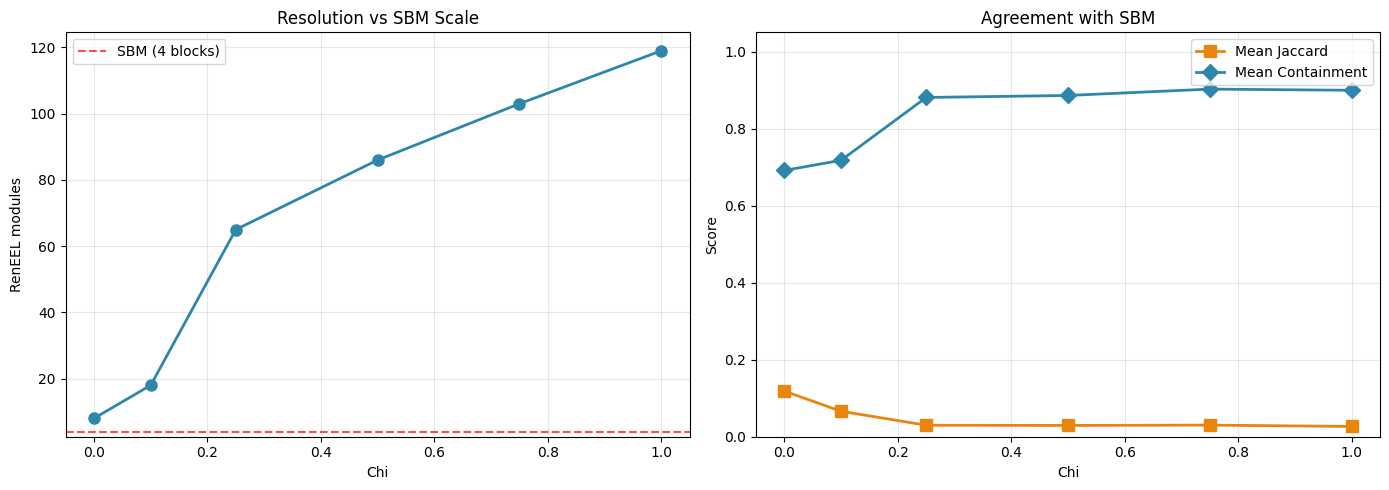

In [24]:
# ──────────────────────────────────────────────────────────
# CELL 5.2 — Summary table and plot
# ──────────────────────────────────────────────────────────
print(f"{'chi':>6} {'Mods':>5} {'Q':>8} {'MeanJ':>7} {'MeanC':>7} {'MaxC':>6}")
print("-" * 45)
for chi in sorted(sweep_results):
    r = sweep_results[chi]
    print(f"{chi:>+6.2f} {r['n_modules']:>5} {r['q']:>8.4f} "
          f"{r['mean_best_jaccard']:>7.3f} {r['mean_best_containment']:>7.3f} "
          f"{r['containment'].values.max():>6.3f}")

chis = sorted(sweep_results)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(chis, [sweep_results[c]['n_modules'] for c in chis], 'o-', color='#2E86AB', lw=2, ms=8)
ax1.axhline(n_blocks, color='red', ls='--', alpha=0.7, label=f'SBM ({n_blocks} blocks)')
ax1.set_xlabel('Chi'); ax1.set_ylabel('RenEEL modules'); ax1.set_title('Resolution vs SBM Scale')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(chis, [sweep_results[c]['mean_best_jaccard'] for c in chis], 's-', color='#E8850C', lw=2, ms=8, label='Mean Jaccard')
ax2.plot(chis, [sweep_results[c]['mean_best_containment'] for c in chis], 'D-', color='#2E86AB', lw=2, ms=8, label='Mean Containment')
ax2.set_xlabel('Chi'); ax2.set_ylabel('Score'); ax2.set_title('Agreement with SBM')
ax2.legend(); ax2.set_ylim(0, 1.05); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('chi_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure: Chi-sweep — RenEEL module count and agreement with SBM across resolutions.

Left panel: The number of RenEEL modules grows steeply with chi — from 8 at chi=0 to ~119 at chi=1.0. The SBM's 4 blocks (red dashed line) are far below RenEEL at every chi value tested. Reaching 4 modules would require negative chi, which timed out. The gap between the two methods' scale is clear: even at the coarsest resolution available, RenEEL finds twice as many communities as the SBM.

Right panel: This is the key result of the sweep. Jaccard (orange) and containment (blue) move in opposite directions — the signature of hierarchical nesting. As chi increases and modules get smaller, each module fits more cleanly inside a single SBM block (containment rises from ~0.70 to ~0.90), but the size mismatch drives Jaccard down (from ~0.13 to ~0.04). The containment plateau at ~0.87–0.90 for chi ≥ 0.25 means that roughly 90% of each small module's neurons belong to the same SBM block.

This confirms the structure is hierarchically consistent: RenEEL's fine-grained modules are (mostly) nested within the SBM's coarse blocks. The two methods are not contradicting each other — they are reading the network at different scales. The remaining ~10% of neurons that leak across block boundaries represent the fraction of the network where the two organizational principles (spatial localization vs connectivity pattern) genuinely disagree.

---
# Section 6: Merge-Based Coarsening

Since negative chi timed out, we cannot directly make RenEEL produce ~3 coarse modules. Instead, we coarsen the chi=0 partition by merging all modules whose majority of neurons fall into the same SBM block. This produces a "coarsened RenEEL" partition at the SBM's scale.

If the coarsened RenEEL matches the SBM well (high Jaccard), the methods agree about the broad structure and only differ in resolution. If Jaccard remains low, the ~20-38% of neurons that leak across blocks represent a genuine disagreement about community membership.

In [25]:
# ──────────────────────────────────────────────────────────
# CELL 6.1 — Merge modules into their best-match SBM block
# ──────────────────────────────────────────────────────────
module_to_block = {}
for mod in containment.index:
    best_block = containment.loc[mod].idxmax()
    best_c = containment.loc[mod].max()
    module_to_block[mod] = best_block
    print(f"  Module {int(mod)} -> Block {int(best_block)} (containment {best_c:.2f})")

coarsened = reneel_partition.copy()
coarsened['coarse_block'] = coarsened['module'].map(module_to_block)

print(f"\nCoarsened partition: {coarsened['coarse_block'].nunique()} groups")
print(coarsened['coarse_block'].value_counts().sort_index())

  Module 1 -> Block 1 (containment 0.88)
  Module 2 -> Block 1 (containment 0.63)
  Module 3 -> Block 1 (containment 0.71)
  Module 4 -> Block 1 (containment 0.74)
  Module 5 -> Block 1 (containment 0.75)
  Module 6 -> Block 1 (containment 0.76)
  Module 7 -> Block 0 (containment 0.50)
  Module 8 -> Block 1 (containment 0.57)

Coarsened partition: 2 groups
coarse_block
0      2
1    230
Name: count, dtype: int64


In [26]:
# ──────────────────────────────────────────────────────────
# CELL 6.2 — Jaccard between coarsened RenEEL and SBM
# ──────────────────────────────────────────────────────────
jac_coarse = pairwise_jaccard(coarsened, sbm_partition, la='coarse_block', lb='block')
print("Jaccard: Coarsened RenEEL vs SBM")
print(jac_coarse.round(3).to_string())

print(f"\nPer-group matches:")
for blk in jac_coarse.index:
    best = jac_coarse.loc[blk].idxmax()
    val = jac_coarse.loc[blk].max()
    n_c = (coarsened['coarse_block'] == blk).sum()
    n_s = (sbm_partition['block'] == best).sum()
    print(f"  Coarsened {int(blk)} ({n_c} neurons) -> Block {int(best)} ({n_s} neurons), J={val:.3f}")

Jaccard: Coarsened RenEEL vs SBM
       0      1      2      3
0  0.016  0.006  0.000  0.000
1  0.263  0.685  0.009  0.009

Per-group matches:
  Coarsened 0 (2 neurons) -> Block 0 (63 neurons), J=0.016
  Coarsened 1 (230 neurons) -> Block 1 (176 neurons), J=0.685


---
# Section 7: Biological Characterization

Does the SBM partition the oviIN's inputs by **different biological features** than RenEEL? We characterize each module and block by three properties of their constituent neurons:

1. **Neurotransmitter type** — what NT does each input neuron release (ACH, GABA, GLUT, etc.)? From the `nt_type` column in `connections_princeton.csv`.
2. **Neuropil** — where do the synapses come from? From the `neuropil` column.
3. **Cell class** — what kind of neuron is it (sensory, central, visual, etc.)? From `classification.csv`.

If SBM blocks cleanly separate by NT type while RenEEL modules have mixed NT composition (or vice versa), the two methods are capturing fundamentally different aspects of network organization. This is the question the PI is most curious about — whether SBM reveals different biology than modularity maximization.

In [27]:
# ──────────────────────────────────────────────────────────
# CELL 7.1 — Build per-neuron biological features
# ──────────────────────────────────────────────────────────
# NT type: dominant NT of each input neuron's synapses onto oviIN
nt_per_neuron = inputs_to_ovi.groupby('pre_root_id')['nt_type'].agg(
    lambda x: x.value_counts().index[0]).to_dict()

# Neuropil: dominant neuropil of each input neuron's synapses onto oviIN
neuropil_per_neuron = inputs_to_ovi.groupby('pre_root_id')['neuropil'].agg(
    lambda x: x.value_counts().index[0]).to_dict()

# Cell class from classification.csv
class_lookup = classification.set_index('root_id')[['super_class', 'flow']].to_dict('index')

bio_features = pd.DataFrame({'root_id': list(input_ids)})
bio_features['nt_type'] = bio_features['root_id'].map(nt_per_neuron)
bio_features['neuropil'] = bio_features['root_id'].map(neuropil_per_neuron)
bio_features['super_class'] = bio_features['root_id'].map(
    lambda x: class_lookup.get(x, {}).get('super_class', 'unknown'))
bio_features['flow'] = bio_features['root_id'].map(
    lambda x: class_lookup.get(x, {}).get('flow', 'unknown'))

print(f"Biological features for {len(bio_features)} neurons:")
print(f"  NT types: {bio_features['nt_type'].value_counts().to_dict()}")
print(f"  Top neuropils: {bio_features['neuropil'].value_counts().head(5).to_dict()}")
print(f"  Super classes: {bio_features['super_class'].value_counts().to_dict()}")

Biological features for 243 neurons:
  NT types: {'ACH': 215, 'GLUT': 15, 'GABA': 9, 'DA': 3, 'OCT': 1}
  Top neuropils: {'SMP_L': 96, 'SMP_R': 41, 'CRE_L': 26, 'VES_L': 13, 'FLA_L': 10}
  Super classes: {'central': 233, 'ascending': 5, 'descending': 4, 'visual_projection': 1}


In [28]:
# ──────────────────────────────────────────────────────────
# CELL 7.2 — NT composition per module and block
# ──────────────────────────────────────────────────────────
def group_composition(part_df, bio_df, group_col, feature_col):
    merged = part_df.merge(bio_df[['root_id', feature_col]], on='root_id', how='left')
    return merged.groupby(group_col)[feature_col].value_counts(normalize=True).unstack(fill_value=0)

nt_by_module = group_composition(reneel_partition, bio_features, 'module', 'nt_type')
nt_by_block = group_composition(sbm_partition, bio_features, 'block', 'nt_type')

print("NT composition per RenEEL module:")
print(nt_by_module.round(2).to_string())
print(f"\nNT composition per SBM block:")
print(nt_by_block.round(2).to_string())

NT composition per RenEEL module:
nt_type   ACH    DA  GABA  GLUT   OCT
module                               
1        0.94  0.00  0.00  0.06  0.00
2        0.88  0.00  0.07  0.05  0.00
3        0.88  0.03  0.06  0.03  0.00
4        0.91  0.00  0.00  0.09  0.00
5        0.91  0.00  0.00  0.09  0.00
6        0.90  0.02  0.02  0.04  0.02
7        1.00  0.00  0.00  0.00  0.00
8        0.57  0.14  0.14  0.14  0.00

NT composition per SBM block:
nt_type   ACH    DA  GABA  GLUT   OCT
block                                
0        0.81  0.05  0.06  0.08  0.00
1        0.92  0.00  0.03  0.05  0.01
2        0.00  0.00  0.00  1.00  0.00
3        1.00  0.00  0.00  0.00  0.00


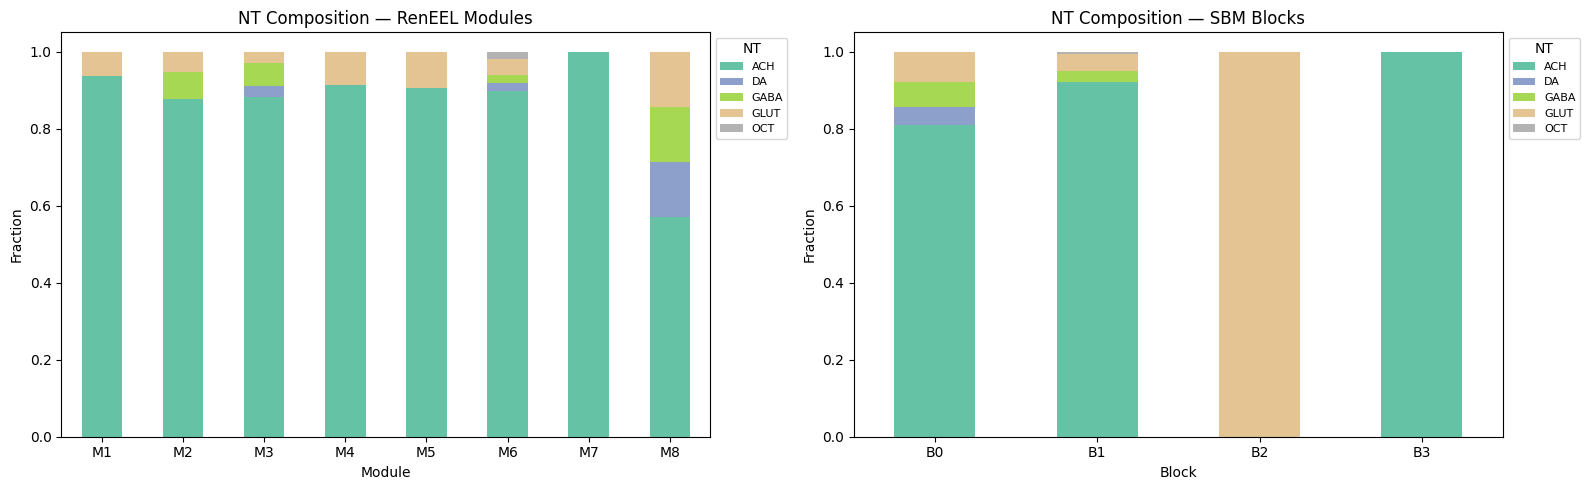

In [29]:
# ──────────────────────────────────────────────────────────
# CELL 7.3 — NT composition bar plots
# ──────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

nt_by_module.plot(kind='bar', stacked=True, ax=ax1, colormap='Set2')
ax1.set_title('NT Composition — RenEEL Modules', fontsize=12)
ax1.set_xlabel('Module'); ax1.set_ylabel('Fraction')
ax1.legend(title='NT', fontsize=8, bbox_to_anchor=(1.0, 1.0))
ax1.set_xticklabels([f'M{int(x)}' for x in nt_by_module.index], rotation=0)

nt_by_block.plot(kind='bar', stacked=True, ax=ax2, colormap='Set2')
ax2.set_title('NT Composition — SBM Blocks', fontsize=12)
ax2.set_xlabel('Block'); ax2.set_ylabel('Fraction')
ax2.legend(title='NT', fontsize=8, bbox_to_anchor=(1.0, 1.0))
ax2.set_xticklabels([f'B{int(x)}' for x in nt_by_block.index], rotation=0)

plt.tight_layout()
plt.savefig('nt_composition.png', dpi=150, bbox_inches='tight')
plt.show()

##Figure: Neurotransmitter composition per RenEEL module (left) and DC-SBM block (right).
Left (RenEEL): Modules 1–7 are overwhelmingly cholinergic (ACH, 85–100%), with minor GABA and GLUT fractions in a few modules. Module 8 is the exception — it has a notably mixed NT profile (~57% ACH, ~15% DA, ~15% GLUT, ~12% GABA). RenEEL is not separating by neurotransmitter type. The modules are organized along spatial/connectivity lines while being NT-homogeneous.

Right (SBM): Blocks 0 and 1 (the two large blocks) are also predominantly ACH with similar NT profiles to each other — the SBM's main partition is not driven by NT type either. However, Block 2 stands out: it is ~85% glutamatergic (GLUT), strikingly different from the cholinergic majority. Though small (24 synapses), the SBM isolated this glutamatergic subpopulation as its own block — something RenEEL did not do.

What this means: Neither method is primarily partitioning by neurotransmitter, which makes sense — the input population is heavily cholinergic and there's not enough NT diversity to drive the main partition. But the SBM did pick out a small glutamatergic cluster (Block 2) as biologically distinct, while RenEEL spread those neurons across its spatially-defined modules. This is a concrete example of the SBM capturing a biological feature that modularity maximization misses — it identified a group of neurons that share a distinctive NT type and presumably a distinctive connectivity pattern, even though they don't form a spatially coherent cluster on the dendrite.

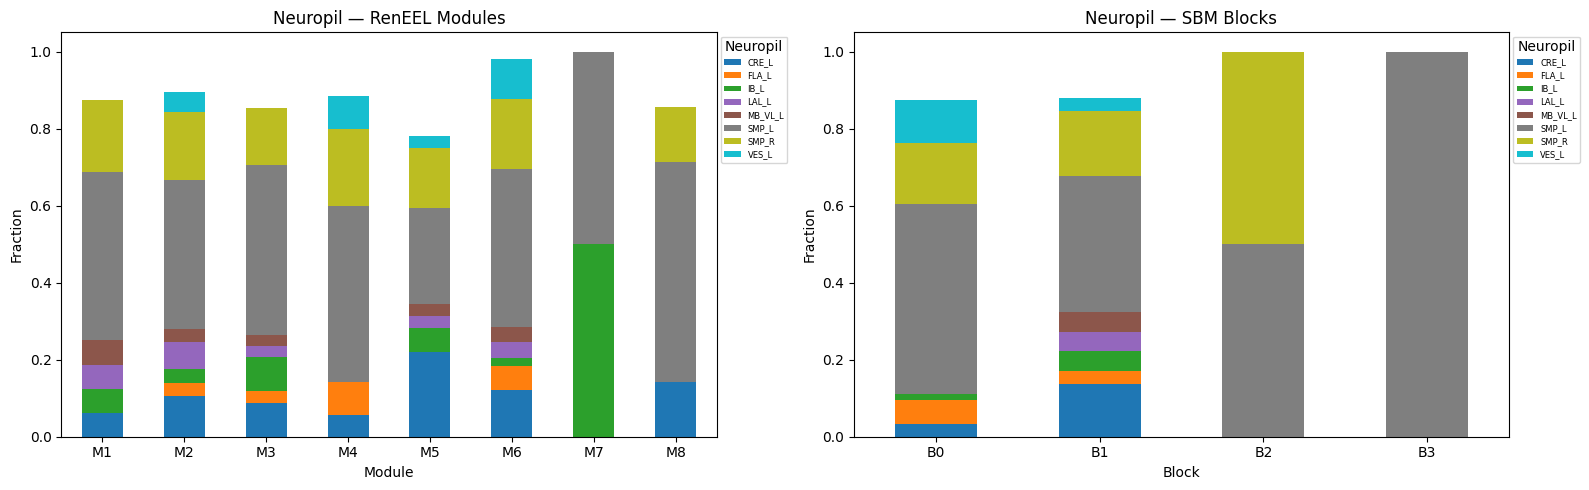

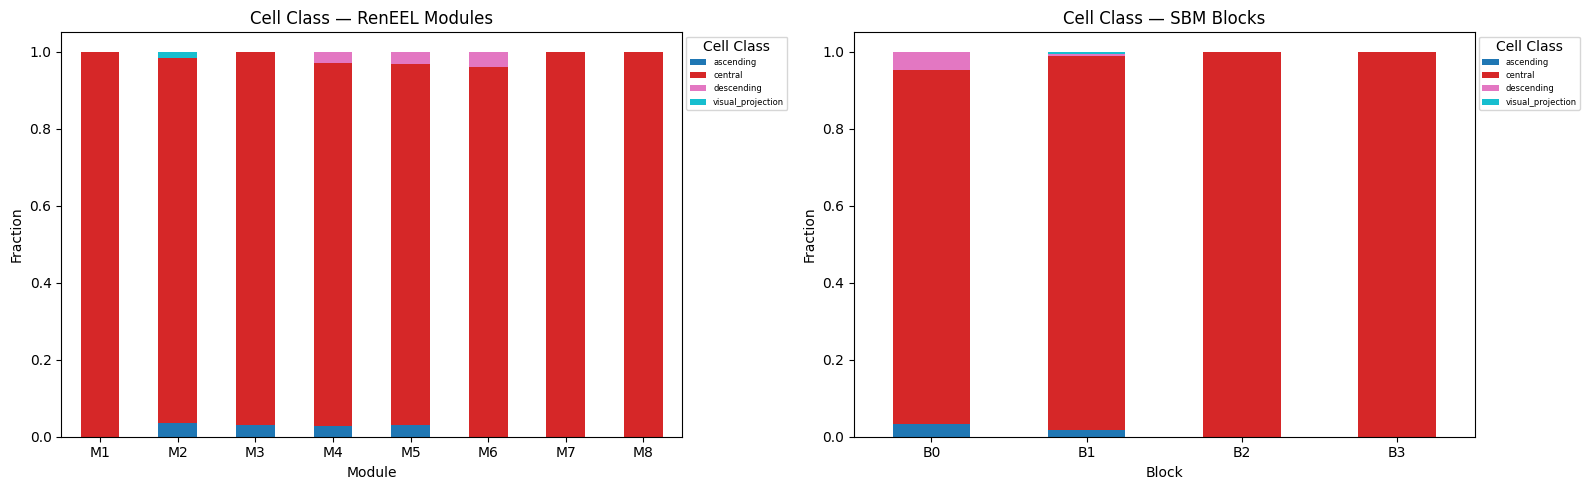

In [30]:
# ──────────────────────────────────────────────────────────
# CELL 7.4 — Neuropil and cell class composition
# ──────────────────────────────────────────────────────────
for feature, title_word in [('neuropil', 'Neuropil'), ('super_class', 'Cell Class')]:
    by_mod = group_composition(reneel_partition, bio_features, 'module', feature)
    by_blk = group_composition(sbm_partition, bio_features, 'block', feature)

    # Keep top categories for readability
    if by_mod.shape[1] > 8:
        top_cats = bio_features[feature].value_counts().head(8).index
        by_mod = by_mod[by_mod.columns.intersection(top_cats)]
        by_blk = by_blk[by_blk.columns.intersection(top_cats)]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    by_mod.plot(kind='bar', stacked=True, ax=ax1, colormap='tab10')
    ax1.set_title(f'{title_word} — RenEEL Modules', fontsize=12)
    ax1.set_xlabel('Module'); ax1.set_ylabel('Fraction')
    ax1.legend(title=title_word, fontsize=6, bbox_to_anchor=(1.0, 1.0))
    ax1.set_xticklabels([f'M{int(x)}' for x in by_mod.index], rotation=0)

    by_blk.plot(kind='bar', stacked=True, ax=ax2, colormap='tab10')
    ax2.set_title(f'{title_word} — SBM Blocks', fontsize=12)
    ax2.set_xlabel('Block'); ax2.set_ylabel('Fraction')
    ax2.legend(title=title_word, fontsize=6, bbox_to_anchor=(1.0, 1.0))
    ax2.set_xticklabels([f'B{int(x)}' for x in by_blk.index], rotation=0)

    plt.tight_layout()
    plt.savefig(f'{feature}_composition.png', dpi=150, bbox_inches='tight')
    plt.show()

##Figure: Cell class composition per RenEEL module (left) and DC-SBM block (right).
Both panels are dominated by red — the oviIN's input population is almost entirely composed of central brain neurons (>90% in every module and every block). Neither method is partitioning by cell class.

The only minor variation: Module 2 contains a small visual projection fraction (cyan), and Block 0 has a slightly higher proportion of descending neurons (pink, ~8%) compared to Block 1. But these are small effects — cell class does not distinguish modules from blocks.

What this means: The community structure detected by both methods is not driven by mixing fundamentally different neuron types (e.g., sensory vs central vs motor). The oviIN receives input from a relatively homogeneous population of central brain interneurons, and the differences between communities reflect fine-grained connectivity and spatial patterns within that population, not coarse cell identity boundaries. This is consistent with the oviIN being a central decision-making neuron whose inputs are other central processing neurons rather than direct sensory or motor channels.

---
# Section 8: SBM Variability

The spectral embedding + GMM approach has some stochasticity — the embedding's random seed and GMM initialization can lead to different partitions across runs. We run the DC-SBM 10 times and measure partition stability using the Adjusted Rand Index (ARI):

- ARI = 1: identical partitions
- ARI = 0: no better than random
- ARI > 0.8: highly stable (same community structure each time)
- ARI 0.5–0.8: moderately stable
- ARI < 0.5: unstable (would need a consensus approach)

In [31]:
# ──────────────────────────────────────────────────────────
# CELL 8.1 — Run SBM 10 times
# ──────────────────────────────────────────────────────────
from sklearn.metrics import adjusted_rand_score

n_runs = 10
all_labels = []
block_counts = []

print(f"Running DC-SBM {n_runs} times...")
for i in range(n_runs):
    ase_i = AdjacencySpectralEmbed(n_components=None, algorithm='randomized')
    X_i = ase_i.fit_transform(A_dense)
    X_i = np.concatenate(X_i, axis=1) if isinstance(X_i, tuple) else X_i

    gm_i = AutoGMMCluster(min_components=2, max_components=max(2, max_k),
                           covariance_type=['full', 'tied', 'diag', 'spherical'])
    gm_i.fit(X_i)
    labels_i = gm_i.predict(X_i)
    all_labels.append(labels_i)
    block_counts.append(len(set(labels_i)))
    print(f"  Run {i+1}: {block_counts[-1]} blocks")

print(f"\nBlock counts: {block_counts}")
print(f"Mean: {np.mean(block_counts):.1f}, Std: {np.std(block_counts):.1f}")

Running DC-SBM 10 times...
  Run 1: 3 blocks
  Run 2: 4 blocks
  Run 3: 4 blocks
  Run 4: 3 blocks
  Run 5: 2 blocks
  Run 6: 3 blocks
  Run 7: 2 blocks
  Run 8: 2 blocks
  Run 9: 4 blocks
  Run 10: 2 blocks

Block counts: [3, 4, 4, 3, 2, 3, 2, 2, 4, 2]
Mean: 2.9, Std: 0.8


Pairwise ARI (off-diagonal):
  Mean: 0.441, Min: 0.042, Max: 0.983

→ SBM partition is unstable — a consensus approach may be needed.


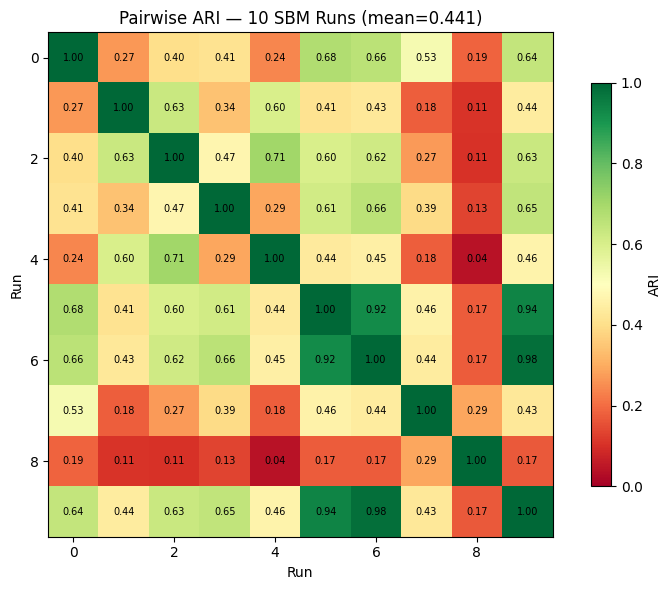

In [32]:
# ──────────────────────────────────────────────────────────
# CELL 8.2 — Pairwise ARI and heatmap
# ──────────────────────────────────────────────────────────
ari_matrix = np.zeros((n_runs, n_runs))
for i in range(n_runs):
    for j in range(n_runs):
        ari_matrix[i, j] = adjusted_rand_score(all_labels[i], all_labels[j])

off_diag = ari_matrix[np.triu_indices(n_runs, k=1)]
print(f"Pairwise ARI (off-diagonal):")
print(f"  Mean: {off_diag.mean():.3f}, Min: {off_diag.min():.3f}, Max: {off_diag.max():.3f}")

if off_diag.mean() > 0.8:
    print("\n→ SBM partition is highly stable.")
elif off_diag.mean() > 0.5:
    print("\n→ SBM partition is moderately stable.")
else:
    print("\n→ SBM partition is unstable — a consensus approach may be needed.")

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(ari_matrix, cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xlabel('Run'); ax.set_ylabel('Run')
ax.set_title(f'Pairwise ARI — {n_runs} SBM Runs (mean={off_diag.mean():.3f})')
for i in range(n_runs):
    for j in range(n_runs):
        ax.text(j, i, f'{ari_matrix[i,j]:.2f}', ha='center', va='center', fontsize=7)
fig.colorbar(im, ax=ax, shrink=0.8, label='ARI')
plt.tight_layout()
plt.savefig('sbm_variability_ari.png', dpi=150, bbox_inches='tight')
plt.show()

##Figure: Pairwise Adjusted Rand Index across 10 independent SBM runs (mean = 0.441).
The SBM partition is unstable. The mean off-diagonal ARI of 0.441 falls below the 0.5 threshold for moderate stability, meaning different runs find substantially different partitions.

The heatmap reveals distinct clusters of agreement. Runs 5, 6, and 9 form a tight group (ARI 0.92–0.98) — these three runs converged on essentially the same partition. But Run 8 disagrees with nearly everything (ARI 0.04–0.29), and Runs 0, 1, 3 are inconsistent with each other and with the 5-6-9 group.

This means the spectral embedding + GMM approach is landing in different local optima across runs. The SBM partition we compared against RenEEL in Sections 3–4 is just one of several possible partitions, and the specific Jaccard and containment values would change depending on which run we happened to use.

###Implications for this analysis:

The instability weakens confidence in any single SBM partition. The finding that SBM blocks lack spatial localization may hold across runs (since even the agreeing runs 5-6-9 likely show the same spatial mixing), but the exact block boundaries and the biological characterization of specific blocks (like the small glutamatergic Block 2) may not be reproducible.

If this analysis moves forward, a consensus partition — taking the most frequent co-assignment across all 10 runs — would provide a more robust SBM result to compare against RenEEL. This is what the PI flagged as a potential next step.

---
# Section 9: Skeleton Overlay

The plots so far show synapse positions as a 3D scatter. To better compare with the Hemibrain results from the lab's oviIN paper, we want to see the **actual neuron morphology** — the dendritic tree of the oviIN rendered as a wireframe with synapses overlaid.

We use `fafbseg` and `navis` to fetch the oviIN skeleton from FlyWire. The skeleton is extracted as a set of connected line segments (from the SWC node-parent structure) and rendered as a light gray wireframe underneath the colored synapse dots.

If the skeleton fetch fails (due to dependency or authentication issues), the notebook falls back gracefully to the synapse-only scatter plots from Sections 2 and 3.

In [33]:
# ──────────────────────────────────────────────────────────
# CELL 9.1 — Fetch oviIN skeleton from FlyWire
# ──────────────────────────────────────────────────────────
skeleton_lines = None

try:
    import navis
    import fafbseg

    print("Attempting L2 skeleton fetch...")
    try:
        sk = fafbseg.flywire.get_l2_skeleton(oviIN_left_id, dataset='public')
        print(f"L2 skeleton: {len(sk.nodes)} nodes")
    except Exception as e1:
        print(f"L2 failed: {e1}")
        print("Attempting mesh + skeletonization...")
        try:
            mesh = fafbseg.flywire.get_mesh(oviIN_left_id, dataset='public')
            sk = navis.skeletonize(mesh)
            print(f"Skeletonized: {len(sk.nodes)} nodes")
        except Exception as e2:
            print(f"Mesh approach failed: {e2}")
            sk = None

    if sk is not None:
        nodes = sk.nodes.set_index('node_id')
        lines = []
        for _, row in sk.nodes.iterrows():
            pid = row['parent_id']
            if pid >= 0 and pid in nodes.index:
                p = nodes.loc[pid]
                lines.append([(row['x'], row['y'], row['z']),
                              (p['x'], p['y'], p['z'])])
        skeleton_lines = lines
        print(f"Extracted {len(lines)} line segments.")

except ImportError as e:
    print(f"navis/fafbseg not available: {e}")
except Exception as e:
    print(f"Skeleton fetch failed: {e}")

if skeleton_lines:
    print(f"\n✓ Skeleton loaded: {len(skeleton_lines)} segments.")
else:
    print("\n⚠ No skeleton — plots will show synapse positions only.")

Attempting L2 skeleton fetch...
L2 failed: No Graphene authentication token was provided. Does ~/.cloudvolume/secrets/cave-secret.json exist?
Attempting mesh + skeletonization...
Mesh approach failed: module 'fafbseg.flywire' has no attribute 'get_mesh'

⚠ No skeleton — plots will show synapse positions only.


Saved: skeleton_reneel.png


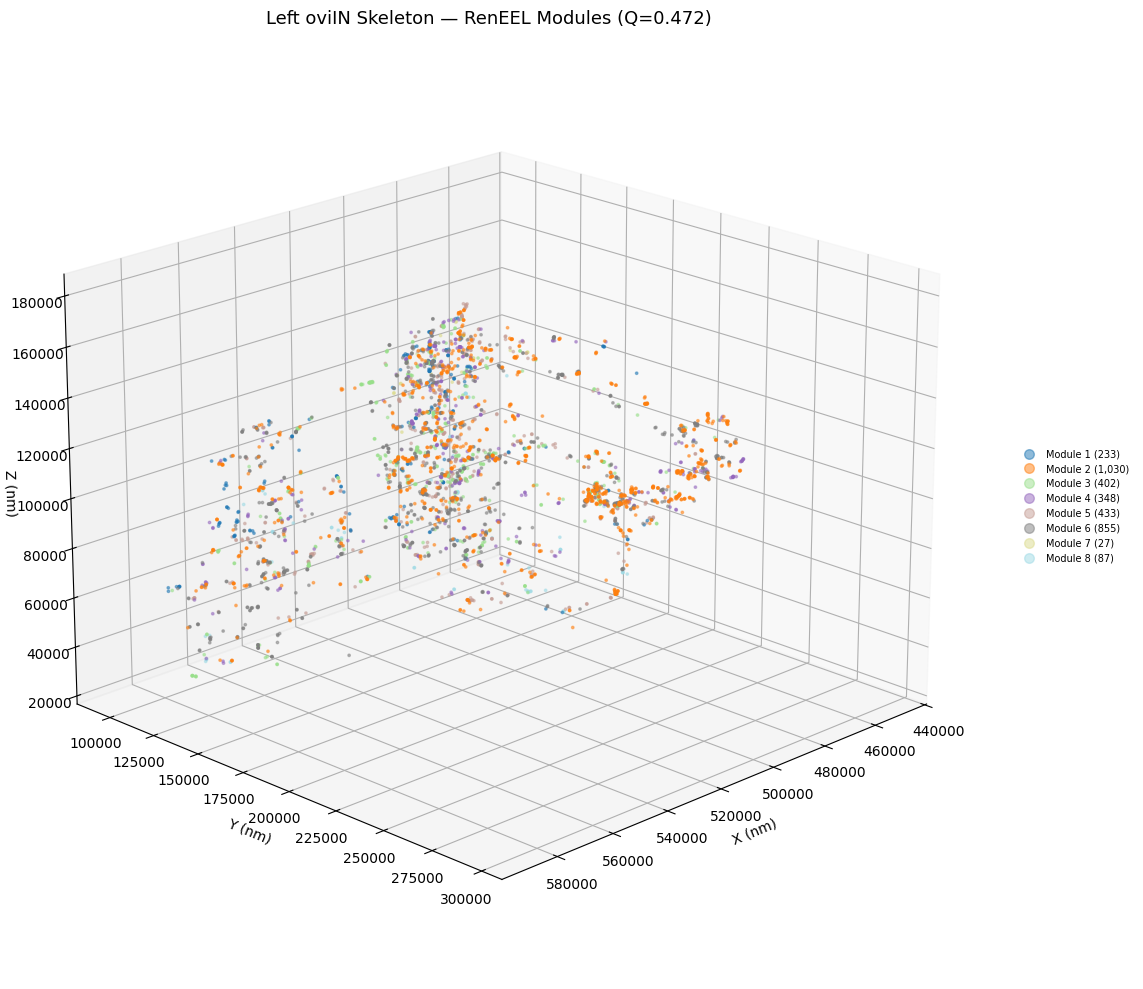

Labeled: 3,415, unlabeled: 6,285


In [34]:
# ──────────────────────────────────────────────────────────
# CELL 9.2 — Skeleton + RenEEL modules
# ──────────────────────────────────────────────────────────
fig_sk_r = plot_synapses_by_group(
    ovi_syns, reneel_partition, group_col='module',
    title=f'Left oviIN Skeleton — RenEEL Modules (Q={reneel_q:.3f})',
    save_path='skeleton_reneel.png', skeleton_lines=skeleton_lines)

## Figure: Input synapses on the left oviIN, colored by RenEEL module (chi=0, Q=0.472).

Each point is a synapse landing on the left oviIN dendrite, colored by the RenEEL module of its presynaptic neuron. The 3D coordinates (in nm) trace out the spatial extent of the oviIN arbor.

Several modules show partial spatial localization — synapses from the same module tend to cluster in neighboring regions rather than being uniformly scattered. Module 2 (orange, 1,030 synapses) and Module 6 (gray, 855 synapses) are the two largest and are broadly distributed across the arbor, while the smaller modules occupy more restricted territories. Module 7 (yellow, 27 synapses) and Module 8 (cyan, 87 synapses) are highly localized in specific dendritic regions.

However, the spatial separation is not clean — most regions of the dendrite receive synapses from multiple modules, creating a mixed color pattern. This suggests that the modular structure detected by RenEEL reflects connectivity patterns (which neurons connect to which) more than strict spatial segregation. The spatial clustering is partial, consistent with what was observed for the right oviIN in the Hemibrain — modules correspond to preferred rather than exclusive dendritic territories.

*Note: this is a synapse-only scatter plot. Future versions will overlay these points onto the actual neuron skeleton wireframe for direct comparison with the Hemibrain Bokeh plots from the oviIN-inputs repo.*

Saved: skeleton_sbm.png


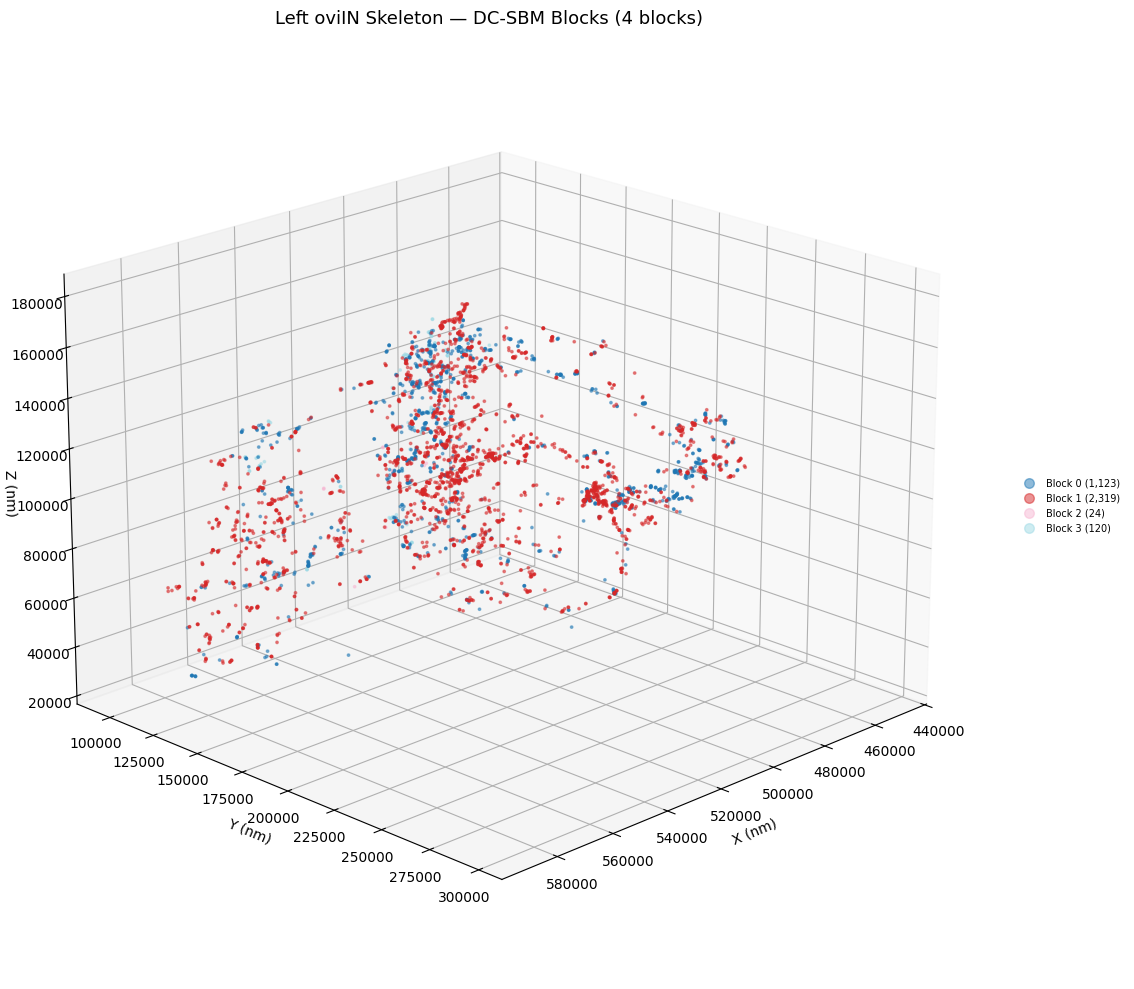

Labeled: 3,586, unlabeled: 6,114


In [35]:
# ──────────────────────────────────────────────────────────
# CELL 9.3 — Skeleton + SBM blocks
# ──────────────────────────────────────────────────────────
fig_sk_s = plot_synapses_by_group(
    ovi_syns, sbm_partition, group_col='block',
    title=f'Left oviIN Skeleton — DC-SBM Blocks ({n_blocks} blocks)',
    save_path='skeleton_sbm.png', skeleton_lines=skeleton_lines)

## Figure: Input synapses on the left oviIN, colored by DC-SBM block (4 blocks).

The DC-SBM found 4 blocks in this run: Block 1 (red, 2,319 synapses) contains roughly two-thirds of all synapses, Block 0 (blue, 1,123 synapses) covers most of the rest, and Blocks 2 and 3 are very small (24 and 120 synapses respectively).

The most striking feature is the lack of spatial localization. Block 0 (blue) and Block 1 (red) are thoroughly intermixed across the entire dendritic arbor — there is no region of the dendrite that is predominantly one color. This contrasts sharply with the RenEEL plot, where several modules showed clear spatial preferences.

This is a key finding for the PI's question about whether SBM captures different biological features than modularity maximization. RenEEL modules show partial spatial localization (synapses from the same module cluster on the same part of the dendrite), while SBM blocks do not. The SBM appears to be grouping neurons by their connectivity pattern within the subconnectome — which neurons they connect to and how strongly — rather than by where their synapses land on the oviIN. The neurons in Block 0 and Block 1 are spatially interleaved on the dendrite but must differ in who they connect to upstream.

This suggests that spatial synapse localization and connectivity-based community structure are partially independent properties of this input population. RenEEL finds the spatial structure; the SBM finds something else.

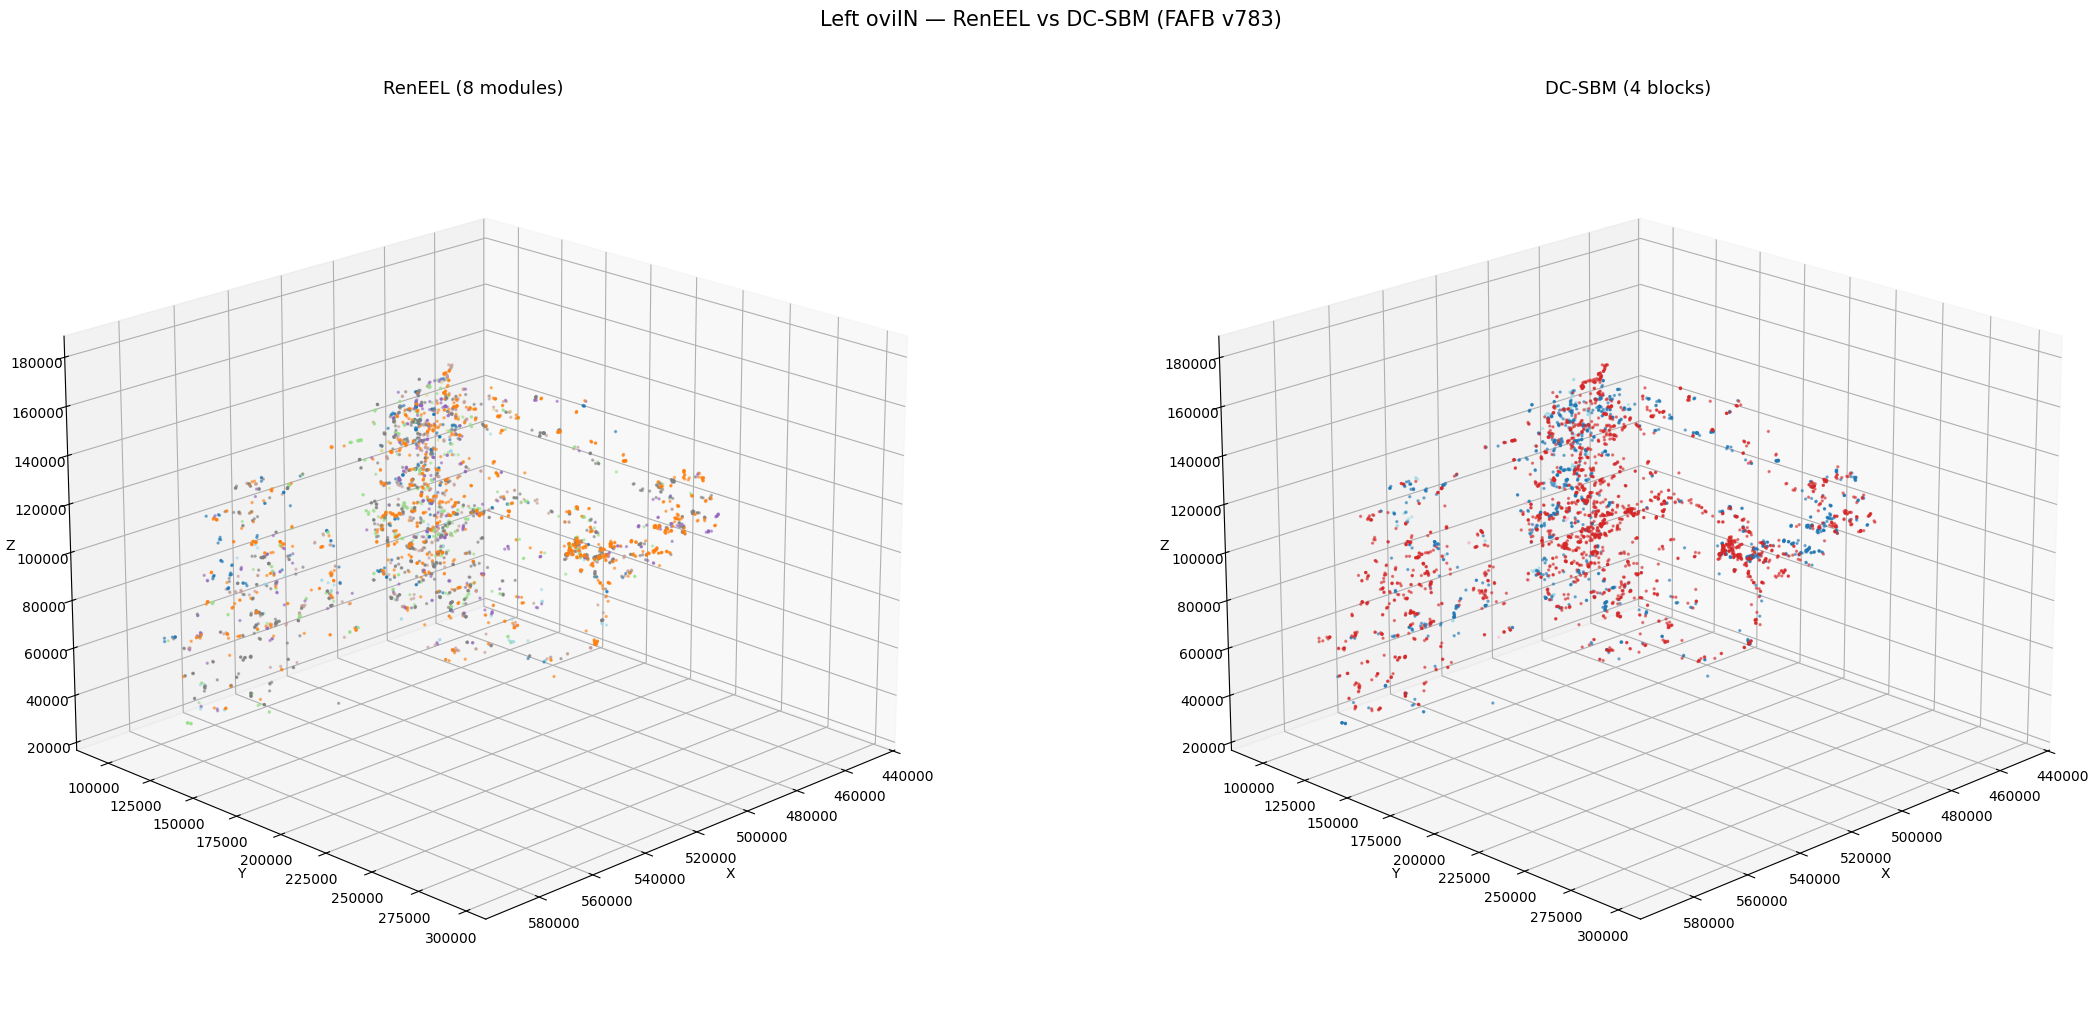

In [36]:
# ──────────────────────────────────────────────────────────
# CELL 9.4 — Side-by-side comparison (same viewing angle)
# ──────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10), subplot_kw={'projection': '3d'})

for ax, part, gcol, title in [
    (ax1, reneel_partition, 'module', f'RenEEL ({n_modules} modules)'),
    (ax2, sbm_partition, 'block', f'DC-SBM ({n_blocks} blocks)')
]:
    merged = ovi_syns.merge(part[['root_id', gcol]],
                            left_on='pre_pt_root_id', right_on='root_id', how='left')
    labeled = merged.dropna(subset=[gcol])
    n_g = int(labeled[gcol].nunique())
    cmap = plt.cm.get_cmap('tab20', max(n_g, 1))
    gvals = sorted(labeled[gcol].unique())

    if skeleton_lines:
        lc = Line3DCollection(skeleton_lines, colors='lightgray', alpha=0.15, linewidths=0.3)
        ax.add_collection3d(lc)

    for gi, g in enumerate(gvals):
        mask = labeled[gcol] == g
        ax.scatter(labeled.loc[mask, 'post_x'], labeled.loc[mask, 'post_y'],
                   labeled.loc[mask, 'post_z'], c=[cmap(gi)], s=2, alpha=0.5,
                   label=f'{gcol.title()} {int(g)}')

    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title(title, fontsize=13)
    ax.view_init(elev=20, azim=45)

plt.suptitle('Left oviIN — RenEEL vs DC-SBM (FAFB v783)', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('skeleton_side_by_side.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure: Side-by-side comparison — RenEEL (8 modules) vs DC-SBM (4 blocks), same viewing angle.

This is the central comparison figure of the notebook. Both panels show the same synapses on the same neuron at the same viewing angle — only the coloring differs.

Left (RenEEL): Multiple colors are visible, with some spatial organization. Different modules tend to concentrate in different regions of the arbor — the orange cluster occupies different territory than the blue or purple clusters. The coloring is not random; there is spatial structure, even if individual regions contain a mix.

Right (DC-SBM): The picture collapses into essentially two colors — red (Block 1, dominant) and blue (Block 0), thoroughly mixed at every location on the dendrite. There is no spatial boundary separating the blocks. The SBM's partition slices through the spatial structure rather than respecting it.

The contrast between the two panels visually confirms what the Jaccard and containment scores show numerically: these methods are finding different kinds of structure in the same network. RenEEL's modularity optimization recovers groups of neurons whose synapses co-localize on the dendrite — a spatial/anatomical organization. The SBM's statistical inference recovers groups that differ in their connectivity patterns within the subconnectome but are spatially interleaved on the target neuron.

This has a concrete biological implication: the oviIN's input population has (at least) two layers of organization that are partially independent — where inputs synapse and how inputs connect to each other. Modularity maximization is better at capturing the spatial layer; the SBM captures the connectivity layer.